In [1]:
%pip install tensorflow opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import numpy as np
import os
import cv2
from matplotlib import pyplot as plt

In [3]:
train_data = tf.keras.utils.image_dataset_from_directory('brain_mri_dataset/Training', validation_split=0.2, subset='training', seed = 42, image_size=(256,256), batch_size=32)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


In [4]:
val_data = tf.keras.utils.image_dataset_from_directory('brain_mri_dataset/Training', validation_split=0.2, subset='validation', seed = 42, image_size=(256,256), batch_size=32)

Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


In [5]:
from collections import Counter

labels = []
for _, y in train_data.unbatch():
    labels.append(y.numpy())

counts = Counter(labels)
for i, name in enumerate(train_data.class_names):
    print(f"{name}: {counts[i]}")

glioma: 1140
meningioma: 1125
notumor: 1100
pituitary: 1115


In [6]:
data_iterator = train_data.as_numpy_iterator()

In [7]:
batch = data_iterator.next()

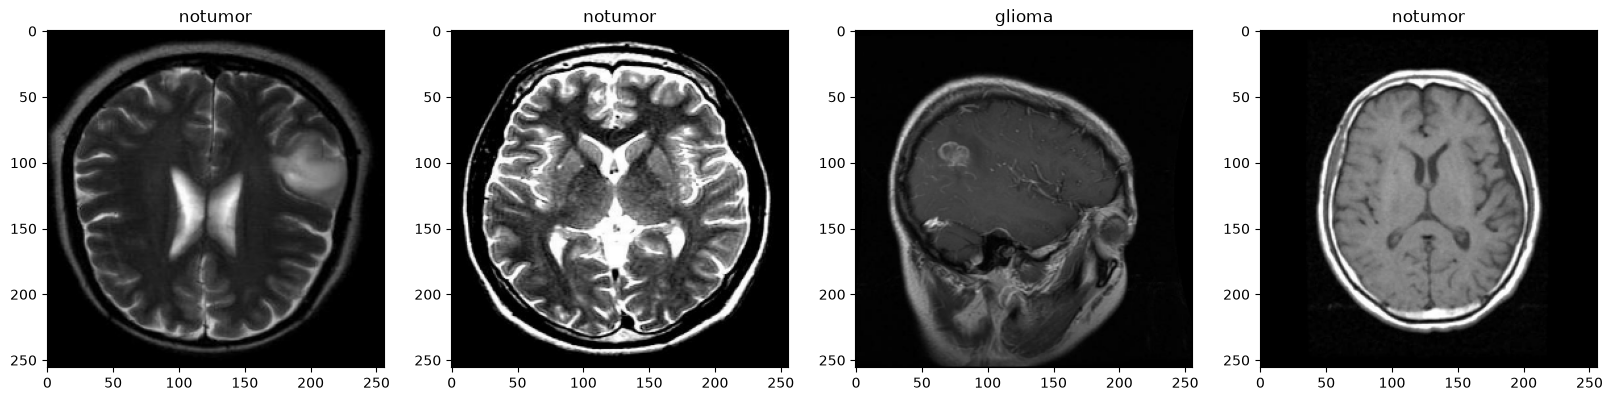

In [8]:
class_names = train_data.class_names
fig, ax = plt.subplots(ncols = 4, figsize = (20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(class_names[batch[1][idx]])

In [9]:
train_data = train_data.map(lambda x,y: (x/255, y))
val_data = val_data.map(lambda x,y: (x/255, y))

In [10]:
scaled = train_data.as_numpy_iterator().next()

In [11]:
scaled[0].max()

np.float32(1.0)

In [12]:
tf.random.set_seed(42)

AUTOTUNE = tf.data.AUTOTUNE
train = train_data.cache().shuffle(1000, seed=42).prefetch(AUTOTUNE)
val = val_data.cache().prefetch(AUTOTUNE)

In [13]:
test_data = tf.keras.utils.image_dataset_from_directory('brain_mri_dataset/Testing')
test_data = test_data.map(lambda x, y: (x/255, y))

Found 1600 files belonging to 4 classes.


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D, Input, RandomRotation, RandomZoom, RandomContrast)

In [15]:
data_augmentation = Sequential([RandomRotation(0.05), RandomContrast(0.1), RandomZoom(0.1)], name="data_augmentation")

In [16]:
model = Sequential()
model.add(Input(shape=(256,256,3)))
model.add(data_augmentation)

model.add(Conv2D(16, (3,3), 1, activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())


model.add(Conv2D(32, (3,3), 1, activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), 1, activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Conv2D(128, (3,3), 1, activation ='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(256, activation ='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(4, activation ='softmax'))

In [17]:
model.compile('adam', loss = tf.losses.SparseCategoricalCrossentropy(), metrics = ['accuracy'])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 254, 254, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 125, 125, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 60, 60, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │              

 Total params: 6,523,236 (24.88 MB)

 Trainable params: 6,522,244 (24.88 MB)

 Non-trainable params: 992 (3.88 KB)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [20]:
hist = model.fit(train, epochs=40, validation_data=val,
                 callbacks=[early_stop, checkpoint, reduce_lr])

C:\Users\miken\OneDrive\Desktop\brain-tumor-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.7212 - loss: 0.7533 - val_accuracy: 0.3411 - val_loss: 18.4832 - learning_rate: 0.0010
Epoch 2/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 137s 978ms/step - accuracy: 0.7871 - loss: 0.5671 - val_accuracy: 0.4563 - val_loss: 15.0110 - learning_rate: 0.0010
Epoch 3/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 108s 767ms/step - accuracy: 0.7996 - loss: 0.5329 - val_accuracy: 0.5429 - val_loss: 1.6870 - learning_rate: 0.0010
Epoch 4/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 112s 802ms/step - accuracy: 0.8364 - loss: 0.4328 - val_accuracy: 0.5286 - val_loss: 2.3946 - learning_rate: 0.0010
Epoch 5/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 123s 881ms/step - accuracy: 0.8641 - loss: 0.3681 - val_accuracy: 0.6080 - val_loss: 2.5502 - learning_rate: 0.0010
Epoch 6/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.8641 - loss: 0.3473 - val_accuracy: 0.6393 - val_loss: 1.2317 - learning_rate: 0.0010
Epoch 7/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 101s 720ms/step - accuracy: 

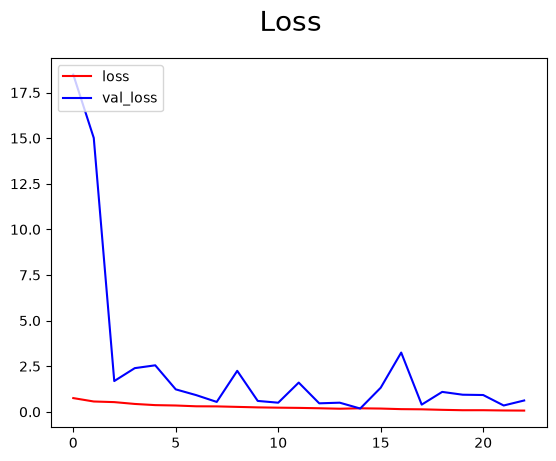

In [27]:
fig = plt.figure()
plt.plot(hist.history['loss'], color = 'red', label = 'loss')
plt.plot(hist.history['val_loss'], color = 'blue', label = 'val_loss')
fig.suptitle('Loss', fontsize = 20)
plt.legend(loc = "upper left")
plt.show()


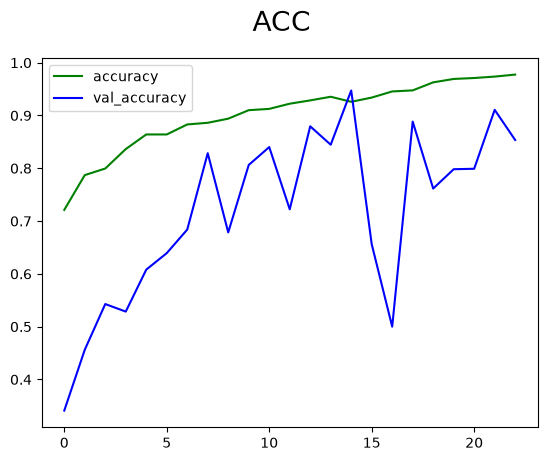

In [28]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color = 'green', label = 'accuracy')
plt.plot(hist.history['val_accuracy'], color = 'blue', label = 'val_accuracy')
fig.suptitle('ACC', fontsize = 20)
plt.legend(loc = "upper left")
plt.show()

In [29]:
best_model = tf.keras.models.load_model('best_model.keras')
best_model.evaluate(test_data)

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 199ms/step - accuracy: 0.8769 - loss: 0.6163


[0.6162566542625427, 0.8768749833106995]

In [30]:
%pip install scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


              precision    recall  f1-score   support

      glioma       0.94      0.75      0.83       400
  meningioma       0.89      0.81      0.85       400
     notumor       0.79      1.00      0.88       400
   pituitary       0.92      0.95      0.94       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



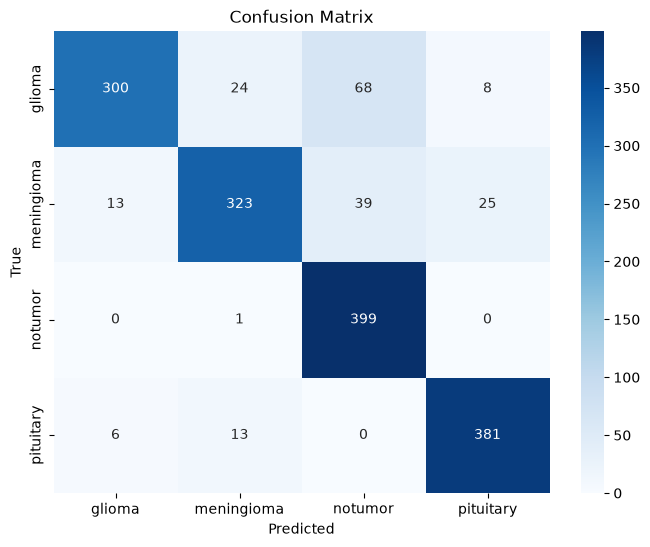

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []
for x, y in test_data:
    preds = model.predict(x, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(y.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [26]:
best_model.save('CNNFinal_v3.0.keras')